# Assignment 1

You only need to write one line of code for each question. When answering questions that ask you to identify or interpret something, the length of your response doesn’t matter. For example, if the answer is just ‘yes,’ ‘no,’ or a number, you can just give that answer without adding anything else.

We will go through comparable code and concepts in the live learning session. If you run into trouble, start by using the help `help()` function in Python, to get information about the datasets and function in question. The internet is also a great resource when coding (though note that **no outside searches are required by the assignment!**). If you do incorporate code from the internet, please cite the source within your code (providing a URL is sufficient).

Please bring questions that you cannot work out on your own to office hours, work periods or share with your peers on Slack. We will work with you through the issue.

### Classification using KNN

Let's set up our workspace and use the **Wine dataset** from `scikit-learn`. This dataset contains 178 wine samples with 13 chemical features, used to classify wines into different classes based on their origin.

The **response variable** is `class`, which indicates the type of wine. We'll use all of the chemical features to predict this response variable.

In [185]:
# Import standard libraries
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score, precision_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [186]:
from sklearn.datasets import load_wine

# Load the Wine dataset
wine_data = load_wine()

# Convert to DataFrame
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)

# Bind the 'class' (wine target) to the DataFrame
wine_df['class'] = wine_data.target

# Display the DataFrame
wine_df


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


#### **Question 1:** 
#### Data inspection

Before fitting any model, it is essential to understand our data. **Use Python code** to answer the following questions about the **Wine dataset**:

_(i)_ How many observations (rows) does the dataset contain?

In [187]:
# Your answer here
num_rows = len(wine_df)
num_rows

178

_(ii)_ How many variables (columns) does the dataset contain?

In [188]:
# Your answer here
num_cols = len(wine_df.columns)
num_cols

14

_(iii)_ What is the 'variable type' of the response variable `class` (e.g., 'integer', 'category', etc.)? What are the 'levels' (unique values) of the variable?

In [189]:
# Your answer here
wine_df.info()

print(f"Data type of 'class' column: {wine_df['class'].dtype}")

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  class           


_(iv)_ How many predictor variables do we have (Hint: all variables other than `class`)? 

In [190]:
# Your answer here
num_predictors = wine_df.drop('class', axis=1).shape[1]
print(f"Number of predictors variables aside from 'class': {num_predictors}")

Number of predictors variables aside from 'class': 13


You can use `print()` and `describe()` to help answer these questions.

#### **Question 2:** 
#### Standardization and data-splitting

Next, we must preform 'pre-processing' or 'data munging', to prepare our data for classification/prediction. For KNN, there are three essential steps. A first essential step is to 'standardize' the predictor variables. We can achieve this using the scaler method, provided as follows:

In [191]:
# Select predictors (excluding the last column)
predictors = wine_df.iloc[:, :-1]

# Standardize the predictors
scaler = StandardScaler()
predictors_standardized = pd.DataFrame(scaler.fit_transform(predictors), columns=predictors.columns)

# Display the head of the standardized predictors
print(predictors_standardized.head())

    alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0  1.518613   -0.562250  0.232053          -1.169593   1.913905   
1  0.246290   -0.499413 -0.827996          -2.490847   0.018145   
2  0.196879    0.021231  1.109334          -0.268738   0.088358   
3  1.691550   -0.346811  0.487926          -0.809251   0.930918   
4  0.295700    0.227694  1.840403           0.451946   1.281985   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0       0.808997    1.034819             -0.659563         1.224884   
1       0.568648    0.733629             -0.820719        -0.544721   
2       0.808997    1.215533             -0.498407         2.135968   
3       2.491446    1.466525             -0.981875         1.032155   
4       0.808997    0.663351              0.226796         0.401404   

   color_intensity       hue  od280/od315_of_diluted_wines   proline  
0         0.251717  0.362177                      1.847920  1.013009  
1        -0.293321  0.406051

(i) Why is it important to standardize the predictor variables?

> We standarlzie and scale predictor variables, because they're not in the same scale of measurament. If they're not on the same sclae,some models can give more weight to variables with larger numericalranges. Is like having age and amount of dollars. The range in amount of dollars can be way wider in real world analysis.

(ii) Why did we elect not to standard our response variable `Class`?

> Class is the target output. Is what we want to predict, so we need to take it out of the data we'll us to predict class and the model would see the answer, and this would led to data leakage. Using class data to predict class data would be circular.So you use "clues" (prediction variables, the "characteristics" of "each "class") and you go from there.

(iii) A second essential step is to set a random seed. Do so below (Hint: use the random.seed function). Why is setting a seed important? Is the particular seed value important? Why or why not?

> Setting a seed is important because it allows models to produce reproducible and consistent results every time they are trained. It helps ensure experiments can be repeated and compared reliably, making random operations reproducible and improving the trustworthiness of the results.

(iv) A third essential step is to split our standardized data into separate training and testing sets. We will split into 75% training and 25% testing. The provided code randomly partitions our data, and creates linked training sets for the predictors and response variables. 

Extend the code to create a non-overlapping test set for the predictors and response variables.

In [ ]:
# set a seed for reproducibility
np.random.seed(123)

## split the data into a training and testing set. hint: use train_test_split !
# defining predictors and target variable for training and testing sets (droping the 'class' column for predictors)
X_full = wine_df.drop(columns=["class"])
y_full = wine_df["class"]

# Split with explicit parameters (train_size=0.75, shuffle=True, stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X_full, 
    y_full,
    train_size=0.75,
    shuffle=True,
    stratify=y_full,
    random_state=42
)

# Standardize the features (fit on training data only!)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), 
    columns=X_test.columns,
    index=X_test.index
)

wine_train, wine_test = train_test_split(wine_df, train_size=0.75, shuffle = True, stratify = wine_df["class"])

#### **Question 3:**
#### Model initialization and cross-validation
We are finally set to fit the KNN model. 


Perform a grid search to tune the `n_neighbors` hyperparameter using 10-fold cross-validation. Follow these steps:

1. Initialize the KNN classifier using `KNeighborsClassifier()`.
2. Define a parameter grid for `n_neighbors` ranging from 1 to 50.
3. Implement a grid search using `GridSearchCV` with 10-fold cross-validation to find the optimal number of neighbors.
4. After fitting the model on the training data, identify and return the best value for `n_neighbors` based on the grid search results.

In [193]:

# initialize the KNN classifier
knn_regressor = KNeighborsClassifier()

# execute a paramgrid search with cross validation to find the best value for n_neighbors
param_grid = {
    "n_neighbors": range(1, 51, 1),
}

# initialize the GridSearchCV object
sacr_grid_search = GridSearchCV(
    estimator=knn_regressor, 
    param_grid=param_grid,
    cv=10,
    scoring="accuracy"
)

sacr_grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(1, 51)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate para

In [194]:
# results of the grid search and print the restults right after
results = pd.DataFrame(sacr_grid_search.cv_results_)
results = (
    results[["param_n_neighbors", "mean_test_score"]]
    .rename(columns={"param_n_neighbors": "n_neighbors", "mean_test_score": "mean_test_score_neg_rmse" })
)

#negative RMSE to RMSE
results["mean_test_score_rmse"] = -results["mean_test_score_neg_rmse"]

print(results)

# print the smallest RMSE value
print(results.nsmallest(1, 'mean_test_score_rmse'))

# print the best value for n_neighbors
best_n_neighbors = sacr_grid_search.best_params_["n_neighbors"]
print(f"Best value for n_neighbors: {best_n_neighbors}")


    n_neighbors  mean_test_score_neg_rmse  mean_test_score_rmse
0             1                  0.946703             -0.946703
1             2                  0.961538             -0.961538
2             3                  0.961538             -0.961538
3             4                  0.962088             -0.962088
4             5                  0.962088             -0.962088
5             6                  0.946703             -0.946703
6             7                  0.969231             -0.969231
7             8                  0.969231             -0.969231
8             9                  0.961538             -0.961538
9            10                  0.961538             -0.961538
10           11                  0.961538             -0.961538
11           12                  0.961538             -0.961538
12           13                  0.969231             -0.969231
13           14                  0.976923             -0.976923
14           15                  0.97692

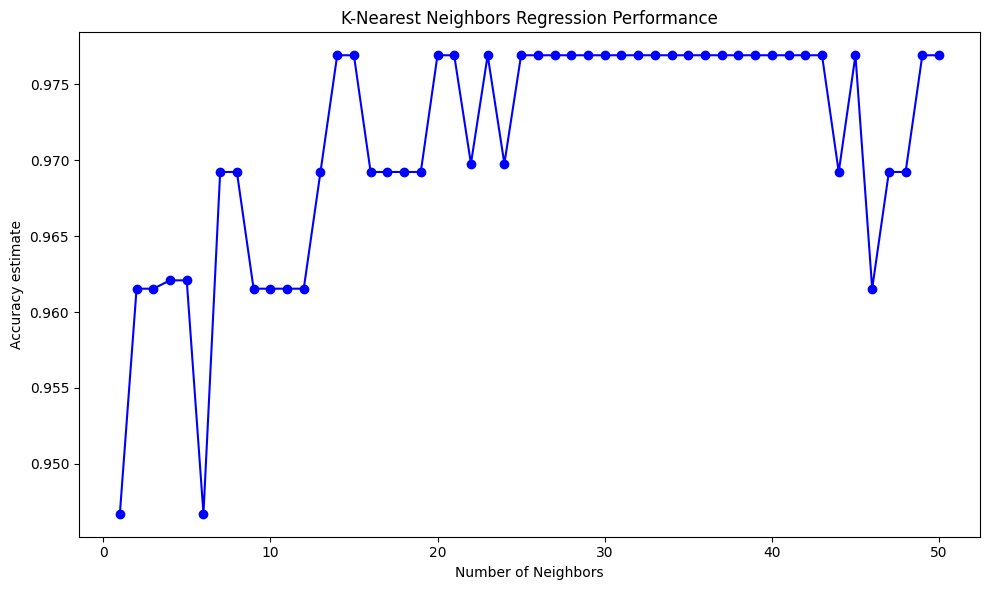

In [195]:
# Create the plot
plt.figure(figsize=(10, 6))

# Plot mean test scores with error bars
plt.plot(results['n_neighbors'], results['mean_test_score_neg_rmse'], '-o', color='blue')

# Add labels and legend
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy estimate')
plt.title('K-Nearest Neighbors Regression Performance')
plt.tight_layout()
plt.show()

#### **Question 4:**
#### Model evaluation

Using the best value for `n_neighbors`, fit a KNN model on the training data and evaluate its performance on the test set using `accuracy_score`.

In [196]:
# best knn model with the best value for n_neighbors
best_knn = KNeighborsClassifier(
    n_neighbors=sacr_grid_search.best_params_["n_neighbors"]
)

best_knn.fit(X_train_scaled, y_train)

# make predictions on test set (using scaled data!)
y_pred = best_knn.predict(X_test_scaled)

# calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the best KNN model on the test set: {accuracy:.4f}")

Accuracy of the best KNN model on the test set: 0.9778


#### **Addition made by João**
#### Model evaluation graphs to visualize the prediction results and performance

Added these graphs to asses the predictions, the accuracy, scores and area under curve to asses visually if the model is doing good 

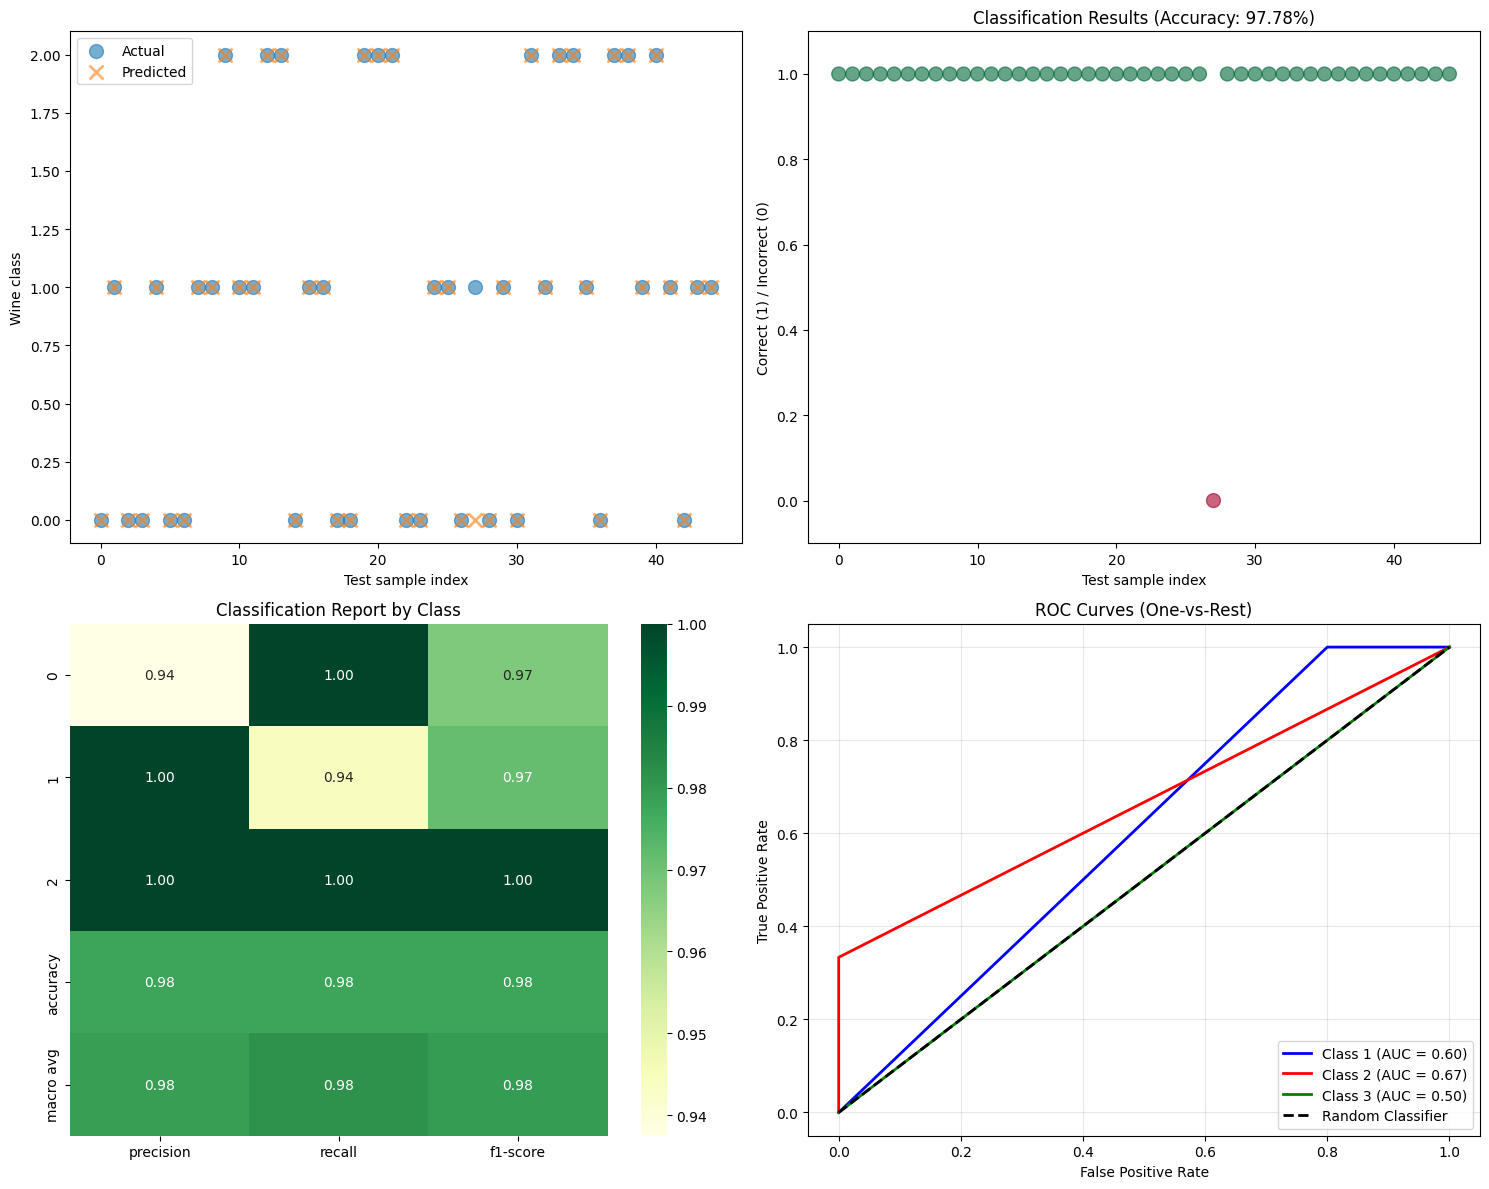

In [197]:
predictions_df = pd.DataFrame({
    "actual": y_test.reset_index(drop=True),
    "predicted": y_pred
})

# Import additional libraries for visualizations
from sklearn.metrics import classification_report
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Scatter plot: Actual vs Predicted by index
matches = (predictions_df["actual"] == predictions_df["predicted"]).astype(int)
axes[0, 0].scatter(predictions_df.index, predictions_df["actual"], label="Actual", s=100, alpha=0.6)
axes[0, 0].scatter(predictions_df.index, predictions_df["predicted"], label="Predicted", s=100, 
                marker='x', alpha=0.6, linewidths=2)
axes[0, 0].set_xlabel("Test sample index")
axes[0, 0].set_ylabel("Wine class")
axes[0, 0].legend()

# 2. Classification results heatmap
axes[0, 1].scatter(range(len(predictions_df)), matches, c=matches, cmap='RdYlGn', s=100, alpha=0.6)
axes[0, 1].set_xlabel("Test sample index")
axes[0, 1].set_ylabel("Correct (1) / Incorrect (0)")
axes[0, 1].set_title(f"Classification Results (Accuracy: {accuracy:.2%})")
axes[0, 1].set_ylim(-0.1, 1.1)

# 3. Classification report heatmap
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
sns.heatmap(report_df.iloc[:-1, :3], annot=True, cmap='YlGn', cbar=True, fmt='.2f', ax=axes[1, 0])
axes[1, 0].set_title('Classification Report by Class')

# 4. ROC Curve (One-vs-Rest for multiclass)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_pred_proba = best_knn.predict_proba(X_test)
n_classes = y_test_bin.shape[1]

colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1, 1].plot(fpr, tpr, color=color, lw=2, label=f'Class {i+1} (AUC = {roc_auc:.2f})')

axes[1, 1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('ROC Curves (One-vs-Rest)')
axes[1, 1].legend(loc="lower right")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Criteria


| **Criteria**                                           | **Complete**                                      | **Incomplete**                                    |
|--------------------------------------------------------|---------------------------------------------------|--------------------------------------------------|
| **Data Inspection**                                    | Data is inspected for number of variables, observations and data types. | Data inspection is missing or incomplete.         |
| **Data Scaling**                                       | Data scaling or normalization is applied where necessary (e.g., using `StandardScaler`). | Data scaling or normalization is missing or incorrectly applied. |
| **Model Initialization**                               | The KNN model is correctly initialized and a random seed is set for reproducibility.            | The KNN model is not initialized, is incorrect, or lacks a random seed for reproducibility. |
| **Parameter Grid for `n_neighbors`**                   | The parameter grid for `n_neighbors` is correctly defined. | The parameter grid is missing or incorrectly defined. |
| **Cross-Validation Setup**                             | Cross-validation is set up correctly with 10 folds. | Cross-validation is missing or incorrectly set up. |
| **Best Hyperparameter (`n_neighbors`) Selection**       | The best value for `n_neighbors` is identified using the grid search results. | The best `n_neighbors` is not selected or incorrect. |
| **Model Evaluation on Test Data**                      | The model is evaluated on the test data using accuracy. | The model evaluation is missing or uses the wrong metric. |


## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Note:

If you like, you may collaborate with others in the cohort. If you choose to do so, please indicate with whom you have worked with in your pull request by tagging their GitHub username. Separate submissions are required.

### Submission Parameters:
* Submission Due Date: `11:59 PM - 05/19/2026`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/LCR/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#dsf1-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
